<a href="https://colab.research.google.com/github/aislam2346/aislam/blob/main/NYC_Taxi_Pipeline_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Taxi Incremental Ingestion Pipeline

**Sections**
1. Setup
2. Pipeline Functions
3. Run Pipeline
4. Raw EDA
5. Staging EDA
6. Gold EDA (Weather Patterns)

## Section 1 -- Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!du -sh "/content/drive/My Drive/ODATA57078"

# Check if Google Drive is already mounted
# import os
# if os.path.exists('/content/drive/MyDrive'):
#     print('Google Drive appears to be mounted.')
#     print('Contents of MyDrive:')
#     print(os.listdir('/content/drive/MyDrive'))
# else:
#     print('Google Drive is not mounted or the mount point is empty.')

# import os

# directory_to_check = '/content/drive/MyDrive/ODATA57078/nyc_taxi_data/'

# if os.path.exists(directory_to_check):
#     print(f"Directory '{directory_to_check}' exists.")

#     # Check writability
#     try:
#         # Attempt to create a temporary file to test writability
#         test_file = os.path.join(directory_to_check, 'test_write.tmp')
#         with open(test_file, 'w') as f:
#             f.write('test')
#         os.remove(test_file) # Clean up the test file
#         print(f"Directory '{directory_to_check}' is writable.")
#     except OSError as e:
#         print(f"Directory '{directory_to_check}' is NOT writable. Error: {e}")
# else:
#     print(f"Directory '{directory_to_check}' does NOT exist.")

4.9G	/content/drive/My Drive/ODATA57078


In [4]:
# Imports
import duckdb
import pandas as pd
import requests
import os
import hashlib
from pathlib import Path
from datetime import datetime, timedelta
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Define directories to NYC Taxi datasets and Duck DB database
# Ensure the parent directory for the DuckDB file exists
os.makedirs("/content/drive/MyDrive/ODATA57078", exist_ok=True)
DB_PATH = "/content/drive/MyDrive/ODATA57078/nyc_taxi_data/taxi.duckdb"

# Other directories
# os.makedirs("/content/drive/MyDrive/ODATA57078/nyc_taxi_data_2019", exist_ok=True)
PARQUET_DIR = "/content/drive/MyDrive/ODATA57078/nyc_taxi_data_2019"
ZONE_LOOKUP_PATH = "/content/drive/MyDrive/ODATA57078/taxi_zone_lookup.csv"
OUTPUT_DIR = Path("/content/drive/MyDrive/ODATA57078/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Training window -- extend this list to add drift test months
MONTHS_TO_INGEST = [
    '2019-01', '2019-02', '2019-03',
    '2019-04', '2019-05', '2019-06',
    '2019-07', '2019-08', '2019-09'
]

# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
})
COLORS = {
    'primary': '#4C9BE8', 'secondary': '#F5A623',
    'green': '#50C878', 'purple': '#A78BFA', 'red': '#E85D75',
}

## Section 2 -- Pipeline Functions

In [6]:
# DuckDB connection + schema bootstrap

def get_connection(db_path=DB_PATH):
    con = duckdb.connect(db_path)
    con.execute('PRAGMA threads=4')
    con.execute("PRAGMA memory_limit='3GB'")
    return con


def bootstrap_schema(con):
    'Create all layers on first run. Idempotent -- safe to call every session.'

    con.execute('''
        CREATE TABLE IF NOT EXISTS pipeline_watermark (
            file_name   VARCHAR PRIMARY KEY,
            file_month  VARCHAR,
            checksum    VARCHAR,
            row_count   BIGINT,
            ingested_at TIMESTAMP,
            layer       VARCHAR
        )
    ''')

    con.execute('''
        CREATE TABLE IF NOT EXISTS raw_taxi_trips (
            VendorID              INTEGER,
            tpep_pickup_datetime  TIMESTAMP,
            tpep_dropoff_datetime TIMESTAMP,
            passenger_count       DOUBLE,
            trip_distance         DOUBLE,
            RatecodeID            DOUBLE,
            store_and_fwd_flag    VARCHAR,
            PULocationID          INTEGER,
            DOLocationID          INTEGER,
            payment_type          BIGINT,
            fare_amount           DOUBLE,
            extra                 DOUBLE,
            mta_tax               DOUBLE,
            tip_amount            DOUBLE,
            tolls_amount          DOUBLE,
            improvement_surcharge DOUBLE,
            total_amount          DOUBLE,
            congestion_surcharge  DOUBLE,
            airport_fee           DOUBLE,
            file_name             VARCHAR,
            file_month            VARCHAR,
            ingested_at           TIMESTAMP
        )
    ''')

    con.execute('''
        CREATE TABLE IF NOT EXISTS staging_taxi_trips (
            VendorID              INTEGER,
            tpep_pickup_datetime  TIMESTAMP,
            tpep_dropoff_datetime TIMESTAMP,
            passenger_count       INTEGER,
            trip_distance         DOUBLE,
            PULocationID          INTEGER,
            DOLocationID          INTEGER,
            payment_type          INTEGER,
            fare_amount           DOUBLE,
            tip_amount            DOUBLE,
            total_amount          DOUBLE,
            congestion_surcharge  DOUBLE,
            trip_duration_mins    DOUBLE,
            pickup_hour           INTEGER,
            pickup_dow            INTEGER,
            pickup_month          INTEGER,
            is_weekend            BOOLEAN,
            time_of_day           VARCHAR,
            file_month            VARCHAR,
            ingested_at           TIMESTAMP,
            rowhash               VARCHAR
        )
    ''')

    con.execute('''
        CREATE TABLE IF NOT EXISTS gold_hourly_demand (
            pickup_hour_ts      TIMESTAMP,
            file_month          VARCHAR,
            PULocationID        INTEGER,
            borough             VARCHAR,
            zone                VARCHAR,
            trip_count          BIGINT,
            avg_trip_distance   DOUBLE,
            avg_fare_amount     DOUBLE,
            avg_duration_mins   DOUBLE,
            avg_passenger_count DOUBLE,
            hour_of_day         INTEGER,
            day_of_week         INTEGER,
            is_weekend          BOOLEAN,
            temperature_2m      DOUBLE,
            precipitation       DOUBLE,
            snowfall            DOUBLE,
            windspeed_10m       DOUBLE,
            weathercode         INTEGER,
            is_snowing          BOOLEAN,
            is_raining          BOOLEAN,
            is_extreme_weather  BOOLEAN
        )
    ''')

    con.execute('''
        CREATE TABLE IF NOT EXISTS weather_hourly (
            weather_ts         TIMESTAMP PRIMARY KEY,
            temperature_2m     DOUBLE,
            precipitation      DOUBLE,
            snowfall           DOUBLE,
            windspeed_10m      DOUBLE,
            weathercode        INTEGER,
            is_snowing         BOOLEAN,
            is_raining         BOOLEAN,
            is_extreme_weather BOOLEAN
        )
    ''')

    print('  Schema bootstrapped (idempotent)')

In [6]:
# Watermark helpers

def file_checksum(path):
    md5 = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            md5.update(chunk)
    return md5.hexdigest()


def is_already_ingested(con, file_name, checksum, layer):
    result = con.execute(
        'SELECT checksum FROM pipeline_watermark WHERE file_name = ? AND layer = ?',
        [file_name, layer]
    ).fetchone()
    if result is None:
        return False
    if result[0] != checksum:
        print(f'  Checksum changed for {file_name} -- re-ingesting')
        return False
    return True


def mark_ingested(con, file_name, file_month, checksum, row_count, layer):
    con.execute('''
        INSERT INTO pipeline_watermark
            (file_name, file_month, checksum, row_count, ingested_at, layer)
        VALUES (?, ?, ?, ?, now(), ?)
        ON CONFLICT (file_name) DO UPDATE SET
            checksum    = excluded.checksum,
            row_count   = excluded.row_count,
            ingested_at = excluded.ingested_at,
            layer       = excluded.layer
    ''', [file_name, file_month, checksum, row_count, layer])

In [7]:
# Layer 1 -- Raw ingestion

def ingest_raw(con, parquet_path, file_month):
    'Load parquet as-is into raw_taxi_trips. Skips if already ingested.'
    file_name = parquet_path.name
    checksum  = file_checksum(parquet_path)

    if is_already_ingested(con, file_name, checksum, layer='raw'):
        print(f'  Raw already ingested: {file_name}')
        return

    con.execute('DELETE FROM raw_taxi_trips WHERE file_name = ?', [file_name])

    con.execute(f'''
        INSERT INTO raw_taxi_trips
        SELECT
            VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
            passenger_count, trip_distance, RatecodeID, store_and_fwd_flag,
            PULocationID, DOLocationID, payment_type, fare_amount, extra,
            mta_tax, tip_amount, tolls_amount, improvement_surcharge,
            total_amount,
            TRY_CAST(congestion_surcharge AS DOUBLE),
            TRY_CAST(airport_fee          AS DOUBLE),
            '{file_name}'  AS file_name,
            '{file_month}' AS file_month,
            now()          AS ingested_at
        FROM read_parquet('{parquet_path}')
    ''')

    row_count = con.execute(
        'SELECT COUNT(*) FROM raw_taxi_trips WHERE file_name = ?', [file_name]
    ).fetchone()[0]

    mark_ingested(con, file_name, file_month, checksum, row_count, layer='raw')
    print(f'  Raw  | {file_name} | {row_count:,} rows')

In [8]:
# Layer 2 -- Staging ingestion

def ingest_staging(con, file_month):
    '''
    Promote one month raw -> staging.
    Cleaning rules:
      R1: Valid timestamps (non-null, pickup < dropoff, correct year)
      R2: Passenger count 1-6
      R3: Fare >= $2.50, total_amount > 0
      R4: Trip distance 0.1-50 miles
      R5: Trip duration 1-150 minutes
    '''
    expected_year = int(file_month.split('-')[0])

    df_audit = con.execute(f'''
        SELECT
            file_month,
            COUNT(*) AS total_rows,
            SUM(CASE WHEN tpep_pickup_datetime IS NULL
                      OR tpep_dropoff_datetime IS NULL
                      OR tpep_pickup_datetime >= tpep_dropoff_datetime
                      OR YEAR(tpep_pickup_datetime)  != {expected_year}
                      OR YEAR(tpep_dropoff_datetime) != {expected_year}
                                                          THEN 1 ELSE 0 END) AS bad_timestamps,
            SUM(CASE WHEN passenger_count IS NULL
                      OR passenger_count < 1
                      OR passenger_count > 6              THEN 1 ELSE 0 END) AS bad_passengers,
            SUM(CASE WHEN fare_amount IS NULL
                      OR fare_amount < 2.50
                      OR total_amount IS NULL
                      OR total_amount <= 0                THEN 1 ELSE 0 END) AS bad_fares,
            SUM(CASE WHEN trip_distance <= 0.1
                      OR trip_distance > 50               THEN 1 ELSE 0 END) AS bad_distance
        FROM raw_taxi_trips
        WHERE file_month = '{file_month}'
        GROUP BY file_month
    ''').fetchdf()
    print(f'\n  Pre-cleaning audit for {file_month}:')
    display(df_audit)

    con.execute('DELETE FROM staging_taxi_trips WHERE file_month = ?', [file_month])

    con.execute(f'''
        INSERT INTO staging_taxi_trips
        SELECT
            VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
            CAST(passenger_count AS INTEGER),
            trip_distance,
            PULocationID, DOLocationID,
            CAST(payment_type AS INTEGER),
            fare_amount, tip_amount, total_amount, congestion_surcharge,
            DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime) AS trip_duration_mins,
            HOUR(tpep_pickup_datetime)                          AS pickup_hour,
            DAYOFWEEK(tpep_pickup_datetime)                     AS pickup_dow,
            MONTH(tpep_pickup_datetime)                         AS pickup_month,
            DAYOFWEEK(tpep_pickup_datetime) IN (0, 6)          AS is_weekend,
            CASE
                WHEN HOUR(tpep_pickup_datetime) BETWEEN 6  AND 11 THEN 'Morning'
                WHEN HOUR(tpep_pickup_datetime) BETWEEN 12 AND 16 THEN 'Afternoon'
                WHEN HOUR(tpep_pickup_datetime) BETWEEN 17 AND 21 THEN 'Evening'
                ELSE 'Night'
            END                                                 AS time_of_day,
            file_month, ingested_at,
            md5(
                COALESCE(CAST(tpep_pickup_datetime  AS VARCHAR), '') ||
                COALESCE(CAST(tpep_dropoff_datetime AS VARCHAR), '') ||
                COALESCE(CAST(PULocationID          AS VARCHAR), '') ||
                COALESCE(CAST(DOLocationID          AS VARCHAR), '') ||
                COALESCE(CAST(fare_amount           AS VARCHAR), '') ||
                COALESCE(CAST(total_amount          AS VARCHAR), '')
            ) AS rowhash
        FROM raw_taxi_trips
        WHERE file_month = '{file_month}'
          AND tpep_pickup_datetime  IS NOT NULL
          AND tpep_dropoff_datetime IS NOT NULL
          AND tpep_pickup_datetime  <  tpep_dropoff_datetime
          AND YEAR(tpep_pickup_datetime)  = {expected_year}
          AND YEAR(tpep_dropoff_datetime) = {expected_year}
          AND passenger_count IS NOT NULL
          AND passenger_count BETWEEN 1 AND 6
          AND fare_amount  IS NOT NULL
          AND fare_amount  >= 2.50
          AND total_amount IS NOT NULL
          AND total_amount >  0
          AND trip_distance BETWEEN 0.1 AND 50
          AND DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime) BETWEEN 1 AND 150
    ''')

    df_sense = con.execute(f'''
        SELECT
            file_month,
            COUNT(*) AS staging_rows,
            (COUNT(rowhash) - COUNT(DISTINCT rowhash)) AS duplicate_hashes,
            SUM(CASE WHEN fare_amount < 2.50    THEN 1 ELSE 0 END) AS bad_fare_remaining,
            SUM(CASE WHEN passenger_count NOT BETWEEN 1 AND 6
                                                THEN 1 ELSE 0 END) AS bad_pax_remaining,
            SUM(CASE WHEN total_amount <= 0     THEN 1 ELSE 0 END) AS bad_total_remaining,
            SUM(CASE WHEN trip_duration_mins NOT BETWEEN 1 AND 150
                                                THEN 1 ELSE 0 END) AS bad_duration_remaining
        FROM staging_taxi_trips
        WHERE file_month = '{file_month}'
        GROUP BY file_month
    ''').fetchdf()
    print(f'\n  Post-cleaning sense check for {file_month}:')
    display(df_sense)

    row_count = int(df_sense['staging_rows'].iloc[0]) if not df_sense.empty else 0
    print(f'  Staging | {file_month} | {row_count:,} rows')

In [9]:
# Layer 3 -- Gold layer

def build_gold(con, file_month, zone_lookup_path=None):
    '''
    Aggregate staging -> gold at hourly grain per pickup zone.
    Joins weather_hourly on exact hour match (1:1).
    Grain: (pickup_hour_ts, PULocationID)
    '''
    try:
        con.execute('SELECT 1 FROM taxi_zones LIMIT 1')
    except Exception:
        src = zone_lookup_path or ZONE_LOOKUP_URL
        df_zones = pd.read_csv(src)
        df_zones.columns = df_zones.columns.str.lower().str.strip()
        con.register('taxi_zones', df_zones)
        print(f'  Zone lookup registered: {len(df_zones)} zones')

    weather_check = con.execute(f'''
        SELECT COUNT(*) FROM weather_hourly
        WHERE weather_ts BETWEEN '{file_month}-01'
                             AND '{file_month}-01'::DATE + INTERVAL 1 MONTH
    ''').fetchone()[0]
    if weather_check == 0:
        print(f'  No weather data for {file_month} -- run ingest_weather() first')
        return

    con.execute('DELETE FROM gold_hourly_demand WHERE file_month = ?', [file_month])

    con.execute(f'''
        INSERT INTO gold_hourly_demand
        SELECT
            DATE_TRUNC('hour', s.tpep_pickup_datetime)   AS pickup_hour_ts,
            s.file_month,
            s.PULocationID, z.borough, z.zone,
            COUNT(*)                                     AS trip_count,
            ROUND(AVG(s.trip_distance),      4)          AS avg_trip_distance,
            ROUND(AVG(s.fare_amount),        4)          AS avg_fare_amount,
            ROUND(AVG(s.trip_duration_mins), 4)          AS avg_duration_mins,
            ROUND(AVG(s.passenger_count),    4)          AS avg_passenger_count,
            HOUR(s.tpep_pickup_datetime)                 AS hour_of_day,
            DAYOFWEEK(s.tpep_pickup_datetime)            AS day_of_week,
            DAYOFWEEK(s.tpep_pickup_datetime) IN (0, 6)  AS is_weekend,
            w.temperature_2m, w.precipitation, w.snowfall,
            w.windspeed_10m, w.weathercode,
            w.is_snowing, w.is_raining, w.is_extreme_weather
        FROM staging_taxi_trips s
        LEFT JOIN taxi_zones z
            ON s.PULocationID = z.locationid
        LEFT JOIN weather_hourly w
            ON DATE_TRUNC('hour', s.tpep_pickup_datetime) = w.weather_ts
        WHERE s.file_month = '{file_month}'
          -- Newark liberty airport (EWR) is not in New York City
          AND z.borough    != 'EWR'
        GROUP BY
            DATE_TRUNC('hour', s.tpep_pickup_datetime),
            s.file_month, s.PULocationID, z.borough, z.zone,
            HOUR(s.tpep_pickup_datetime), DAYOFWEEK(s.tpep_pickup_datetime),
            DAYOFWEEK(s.tpep_pickup_datetime) IN (0, 6),
            w.temperature_2m, w.precipitation, w.snowfall,
            w.windspeed_10m, w.weathercode,
            w.is_snowing, w.is_raining, w.is_extreme_weather
    ''')

    row_count = con.execute(
        'SELECT COUNT(*) FROM gold_hourly_demand WHERE file_month = ?', [file_month]
    ).fetchone()[0]
    print(f'  Gold | {file_month} | {row_count:,} hourly zone records')

In [10]:
# Weather ingestion

def ingest_weather(con, start_date='2019-01-01', end_date='2020-06-30'):
    '''
    Fetch hourly weather from Open-Meteo archive API.
    Watermark-based -- resumes from last loaded hour.

    Units: temperature_2m=C, precipitation=mm, snowfall=cm, windspeed=km/h
    Verify on first run by checking the printed API units output.

    Extreme weather thresholds:
      snowfall > 7.62 cm (~3 inches)
      precipitation > 25.4 mm (~1 inch)
    '''
    last_ts = con.execute('SELECT MAX(weather_ts) FROM weather_hourly').fetchone()[0]

    if last_ts is not None:
        fetch_from = str((last_ts + timedelta(hours=1)).date())
        if fetch_from > end_date:
            total = con.execute('SELECT COUNT(*) FROM weather_hourly').fetchone()[0]
            print(f'  Weather already loaded up to {last_ts} ({total:,} hours)')
            return
        print(f'  Resuming weather from {fetch_from} to {end_date}')
    else:
        fetch_from = start_date
        print(f'  Fetching hourly weather {fetch_from} to {end_date}')

    response = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': 40.7128, 'longitude': -74.0060,
            'start_date': fetch_from, 'end_date': end_date,
            'hourly': ['temperature_2m', 'precipitation', 'snowfall',
                       'windspeed_10m', 'weathercode'],
            'timezone': 'America/New_York',
            'temperature_unit': 'celsius',
        },
        timeout=60
    )
    response.raise_for_status()
    data = response.json()
    print(f"  API units: {data.get('hourly_units', 'not returned')}")

    hourly = data.get('hourly', {})
    if not hourly or not hourly.get('time'):
        print('  No hourly data returned -- check date range')
        return

    df = pd.DataFrame({
        'weather_ts':    pd.to_datetime(hourly['time']).floor('h'),
        'temperature_2m': hourly['temperature_2m'],
        'precipitation':  hourly['precipitation'],
        'snowfall':       hourly['snowfall'],
        'windspeed_10m':  hourly['windspeed_10m'],
        'weathercode':    hourly['weathercode'],
    })
    df['is_snowing']         = df['snowfall'].fillna(0) > 0
    df['is_raining']         = (df['precipitation'].fillna(0) > 0) & (~df['is_snowing'])
    df['is_extreme_weather'] = (
        (df['snowfall'].fillna(0)      > 7.62) |
        (df['precipitation'].fillna(0) > 25.4)
    )

    con.register('weather_temp', df)
    con.execute('''
        INSERT OR REPLACE INTO weather_hourly
        SELECT CAST(weather_ts AS TIMESTAMP),
               temperature_2m, precipitation, snowfall, windspeed_10m,
               CAST(weathercode AS INTEGER),
               is_snowing, is_raining, is_extreme_weather
        FROM weather_temp
    ''')

    total = con.execute('SELECT COUNT(*) FROM weather_hourly').fetchone()[0]
    print(f'  Weather loaded: {total:,} hourly records')

## Section 3 -- Run Pipeline

Run cells in order. Pipeline is idempotent -- already-ingested months are skipped.
Raw parquet files are read directly from Google Drive (no re-downloading needed).

In [8]:
# 3.1.1 Initialise connection
import os

# Check if the DuckDB file exists and remove it if it's potentially corrupted.
# This is a common workaround for "IO Error: Could not read enough bytes"
# when a DuckDB file might be corrupted from an interrupted previous run.
if os.path.exists(DB_PATH):
    try:
        # Attempt to connect in read-only mode to check for corruption
        test_con = duckdb.connect(DB_PATH, read_only=True)
        test_con.close()
    except duckdb.IOException as e:
        print(f"Warning: DuckDB file at {DB_PATH} appears corrupted ({e}). Deleting and recreating.")
        os.remove(DB_PATH)
    except Exception as e:
        # Catch other potential connection issues as well
        print(f"Warning: Could not open DuckDB file at {DB_PATH} for read-only check ({e}). Deleting and recreating.")
        os.remove(DB_PATH)

con = get_connection(DB_PATH)

To see the files that have been ingested, query the `pipeline_watermark` table:

In [12]:
display(con.execute('SELECT * FROM pipeline_watermark ORDER BY ingested_at DESC').fetchdf())

,file_name,file_month,checksum,row_count,ingested_at,layer


In [11]:
# 3.1.2 Define schema
bootstrap_schema(con)

  Schema bootstrapped (idempotent)


In [13]:
# import os
# if os.path.exists(DB_PATH):
#     print(f"The DuckDB file exists at: {DB_PATH}")
#     print(f"Size: {os.path.getsize(DB_PATH)/1024/1024:.2f} MB")
# else:
#     print(f"The DuckDB file does NOT exist at: {DB_PATH}")

In [14]:
# 3.2 Load weather -- fetches once, resumes if interrupted
ingest_weather(con)

  Weather already loaded up to 2020-06-30 23:00:00 (13,128 hours)


In [15]:
# 3.3 Main pipeline loop: raw -> staging -> gold per month
PARQUET_DRIVE = Path(PARQUET_DIR)

for month in MONTHS_TO_INGEST:
    print(f'\n{"="*55}')
    print(f'  Processing: {month}')
    print(f'{"="*55}')

    parquet_path = PARQUET_DRIVE / f'yellow_tripdata_{month}.parquet'

    if not parquet_path.exists():
        print(f'  File not found: {parquet_path.name} -- skipping')
        continue

    ingest_raw(con, parquet_path, month)
    ingest_staging(con, month)
    build_gold(con, month, zone_lookup_path=ZONE_LOOKUP_PATH)

con.execute('CHECKPOINT')
print('\nPipeline complete')
print(f'DuckDB size on Drive: {os.path.getsize(DB_PATH)/1024/1024:.1f} MB')


  Processing: 2019-01
  Raw already ingested: yellow_tripdata_2019-01.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Pre-cleaning audit for 2019-01:


,file_month,total_rows,bad_timestamps,bad_passengers,bad_fares,bad_distance
0,2019-01,7696617,6997.0,146110.0,10879.0,79210.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...


  Post-cleaning sense check for 2019-12:


,file_month,staging_rows,duplicate_hashes,bad_fare_remaining,bad_pax_remaining,bad_total_remaining,bad_duration_remaining
0,2019-12,6591564,1,0.0,0.0,0.0,0.0


  Staging | 2019-12 | 6,591,564 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Gold | 2019-12 | 82,078 hourly zone records

Pipeline complete
DuckDB size on Drive: 5034.5 MB


In [16]:
# 3.4 Sanity checks -- run these before EDA

print('1. Weather coverage:')
display(con.execute('''
    SELECT MIN(weather_ts) AS from_ts, MAX(weather_ts) AS to_ts,
           COUNT(*) AS total_hours
    FROM weather_hourly
''').fetchdf())

print('\n2. Gold row counts per month:')
display(con.execute('''
    SELECT file_month,
           COUNT(*) AS hourly_zone_records,
           SUM(trip_count) AS total_trips
    FROM gold_hourly_demand
    GROUP BY file_month ORDER BY file_month
''').fetchdf())

print('\n3. Missing weather in gold (should be 0):')
display(con.execute('''
    SELECT COUNT(*) AS missing_weather_rows
    FROM gold_hourly_demand WHERE temperature_2m IS NULL
''').fetchdf())

1. Weather coverage:


,from_ts,to_ts,total_hours
0,2019-01-01,2020-06-30 23:00:00,13128



2. Gold row counts per month:


,file_month,hourly_zone_records,total_trips
0,2019-01,99434,7445927.0
1,2019-02,92088,6804345.0
2,2019-03,101953,7587178.0
3,2019-04,92316,7195178.0
4,2019-05,93013,7310616.0
5,2019-06,90528,6696872.0
6,2019-07,89016,6043305.0
7,2019-08,85684,5811603.0
8,2019-09,83562,6291343.0
9,2019-10,83529,6904990.0



3. Missing weather in gold (should be 0):


,missing_weather_rows
0,0


## Section 4 -- Raw EDA

Validate data quality before cleaning.

In [17]:
# 4.1 Preview raw table
# display(con.execute('SELECT * FROM raw_taxi_trips LIMIT 5').fetchdf())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,file_name,file_month,ingested_at
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,...,0.5,1.65,0.0,0.3,9.95,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-27 11:04:42.922
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,...,0.5,1.00,0.0,0.3,16.30,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-27 11:04:42.922
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,...,0.5,0.00,0.0,0.3,5.80,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-27 11:04:42.922
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,...,0.5,0.00,0.0,0.3,7.55,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-27 11:04:42.922
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,...,0.5,0.00,0.0,0.3,55.55,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-27 11:04:42.922


In [18]:
# 4.2 Row counts per month
# display(con.execute('''
#     SELECT file_month, COUNT(*) AS total_rows
#     FROM raw_taxi_trips
#     GROUP BY file_month ORDER BY file_month
# ''').fetchdf())

,file_month,total_rows
0,2019-01,7696617
1,2019-02,7049370
2,2019-03,7866620
3,2019-04,7475949
4,2019-05,7598445
5,2019-06,6971560
6,2019-07,6310419
7,2019-08,6073357
8,2019-09,6567788
9,2019-10,7213891


In [19]:
# 4.3 Null counts
# display(con.execute('''
#     SELECT
#         COUNT(*) AS total_rows,
#         COUNT(*) - COUNT(tpep_pickup_datetime)  AS null_pickup,
#         COUNT(*) - COUNT(tpep_dropoff_datetime) AS null_dropoff,
#         COUNT(*) - COUNT(passenger_count)       AS null_passengers,
#         COUNT(*) - COUNT(trip_distance)         AS null_distance,
#         COUNT(*) - COUNT(fare_amount)           AS null_fare,
#         COUNT(*) - COUNT(total_amount)          AS null_total,
#         COUNT(*) - COUNT(PULocationID)          AS null_pickup_loc,
#         COUNT(*) - COUNT(DOLocationID)          AS null_dropoff_loc,
#         COUNT(*) - COUNT(congestion_surcharge)  AS null_congestion
#     FROM raw_taxi_trips
# ''').fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,null_pickup,null_dropoff,null_passengers,null_distance,null_fare,null_total,null_pickup_loc,null_dropoff_loc,null_congestion
0,84598444,0,0,444383,0,0,0,0,0,5300601


In [20]:
# 4.4 Out of range values per month
# display(con.execute('''
#     SELECT
#         file_month,
#         SUM(CASE WHEN fare_amount <= 0    THEN 1 ELSE 0 END) AS negative_fare,
#         SUM(CASE WHEN fare_amount > 500   THEN 1 ELSE 0 END) AS extreme_fare,
#         SUM(CASE WHEN trip_distance <= 0  THEN 1 ELSE 0 END) AS zero_distance,
#         SUM(CASE WHEN trip_distance > 100 THEN 1 ELSE 0 END) AS extreme_distance,
#         SUM(CASE WHEN passenger_count < 1 THEN 1 ELSE 0 END) AS zero_passengers,
#         SUM(CASE WHEN passenger_count > 6 THEN 1 ELSE 0 END) AS too_many_passengers,
#         SUM(CASE WHEN tpep_dropoff_datetime <= tpep_pickup_datetime
#                                             THEN 1 ELSE 0 END) AS invalid_timestamps,
#         COUNT(*) AS total_rows
#     FROM raw_taxi_trips
#     GROUP BY file_month ORDER BY file_month
# ''').fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,file_month,negative_fare,extreme_fare,zero_distance,extreme_distance,zero_passengers,too_many_passengers,invalid_timestamps,total_rows
0,2019-01,9770.0,34.0,55089.0,32.0,117381.0,57.0,6557.0,7696617
1,2019-02,12344.0,12.0,49784.0,17.0,119150.0,72.0,6395.0,7049370
2,2019-03,14791.0,19.0,53819.0,24.0,140131.0,82.0,6242.0,7866620
3,2019-04,14847.0,18.0,50966.0,32.0,136807.0,72.0,6254.0,7475949
4,2019-05,16587.0,28.0,56354.0,23.0,143805.0,79.0,7682.0,7598445
5,2019-06,17150.0,24.0,63075.0,38.0,128130.0,91.0,8994.0,6971560
6,2019-07,16017.0,29.0,67669.0,34.0,116884.0,67.0,8223.0,6310419
7,2019-08,17682.0,34.0,69155.0,38.0,110319.0,83.0,6975.0,6073357
8,2019-09,18773.0,34.0,71182.0,24.0,120514.0,77.0,5991.0,6567788
9,2019-10,21255.0,14.0,69913.0,15.0,137577.0,79.0,5219.0,7213891


In [21]:
# 4.5 Duplicate check
# display(con.execute('''
#     SELECT COUNT(*) AS duplicate_rows
#     FROM (
#         SELECT tpep_pickup_datetime, tpep_dropoff_datetime,
#                PULocationID, DOLocationID, total_amount, COUNT(*) AS cnt
#         FROM raw_taxi_trips
#         GROUP BY ALL HAVING COUNT(*) > 1
#     )
# ''').fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_rows
0,1836


## Section 5 -- Staging EDA

Core EDA findings for your proposal. Run after staging ingestion is complete.

In [22]:
# 5.1 Preview staging table
display(con.execute('SELECT * FROM staging_taxi_trips LIMIT 5').fetchdf())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,...,congestion_surcharge,trip_duration_mins,pickup_hour,pickup_dow,pickup_month,is_weekend,time_of_day,file_month,ingested_at,rowhash
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,151,239,1,7.0,1.65,...,NaN,7.0,0,2,1,False,Night,2019-01,2026-03-27 11:04:42.922,b810556cf858ab9876d5a2d91aba0412
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,239,246,1,14.0,1.00,...,NaN,19.0,0,2,1,False,Night,2019-01,2026-03-27 11:04:42.922,bdfeb649d2d45efc402bc8c405503d61
2,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1,1.3,163,229,1,6.5,1.25,...,NaN,7.0,0,2,1,False,Night,2019-01,2026-03-27 11:04:42.922,f1f8446576e9bf0d237cfd2ccc4facf6
3,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1,3.7,229,7,1,13.5,3.70,...,NaN,13.0,0,2,1,False,Night,2019-01,2026-03-27 11:04:42.922,5e1928fca69b5c1823a603e7b5e44839
4,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2,2.1,141,234,1,10.0,1.70,...,NaN,12.0,0,2,1,False,Night,2019-01,2026-03-27 11:04:42.922,819612b5bf8c7b3471adcb7cc925c335


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

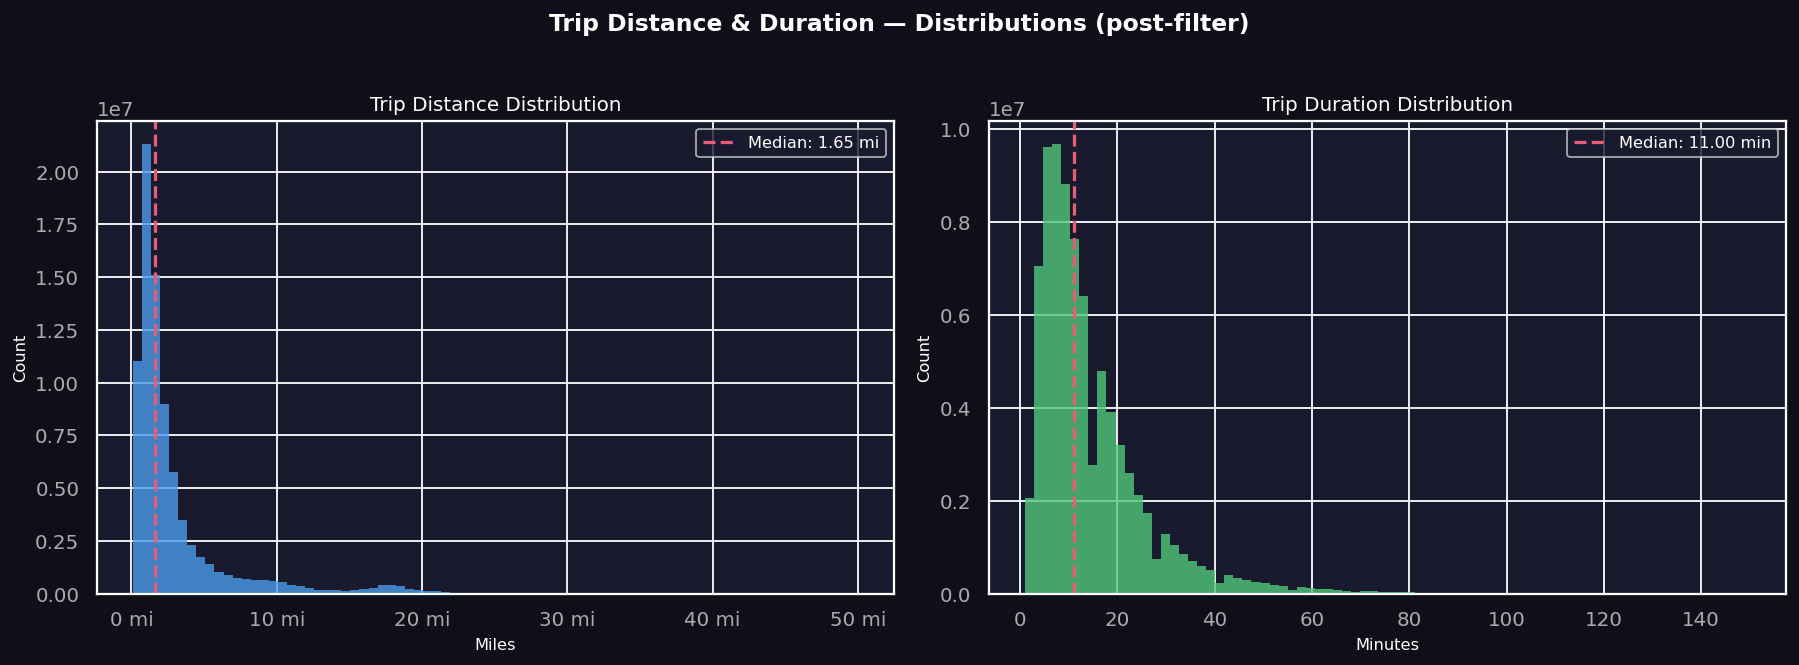

  Saved: 01a_distributions.png


In [23]:
# Figure 1: Histograms with median lines

df_dist = con.execute("""
    SELECT trip_distance, trip_duration_mins, file_month
    FROM staging_taxi_trips
    WHERE trip_distance      BETWEEN 0.1 AND 50
      AND trip_duration_mins BETWEEN 1   AND 150
""").fetchdf()

median_distance = df_dist["trip_distance"].median()
median_duration = df_dist["trip_duration_mins"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Trip Distance & Duration — Distributions (post-filter)",
             fontsize=13, fontweight="bold", color="white", y=1.02)

# Distance histogram
ax = axes[0]
ax.hist(df_dist["trip_distance"], bins=80,
        color="#4C9BE8", alpha=0.8, edgecolor="none")
ax.axvline(median_distance, color="#E85D75", linewidth=1.8,
           linestyle="--", label=f"Median: {median_distance:.2f} mi")
ax.set_title("Trip Distance Distribution")
ax.set_xlabel("Miles")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f mi"))
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9)

# Duration histogram
ax = axes[1]
ax.hist(df_dist["trip_duration_mins"], bins=80,
        color="#50C878", alpha=0.8, edgecolor="none")
ax.axvline(median_duration, color="#E85D75", linewidth=1.8,
           linestyle="--", label=f"Median: {median_duration:.2f} min")
ax.set_title("Trip Duration Distribution")
ax.set_xlabel("Minutes")
ax.set_ylabel("Count")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01a_distributions.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("  Saved: 01a_distributions.png")



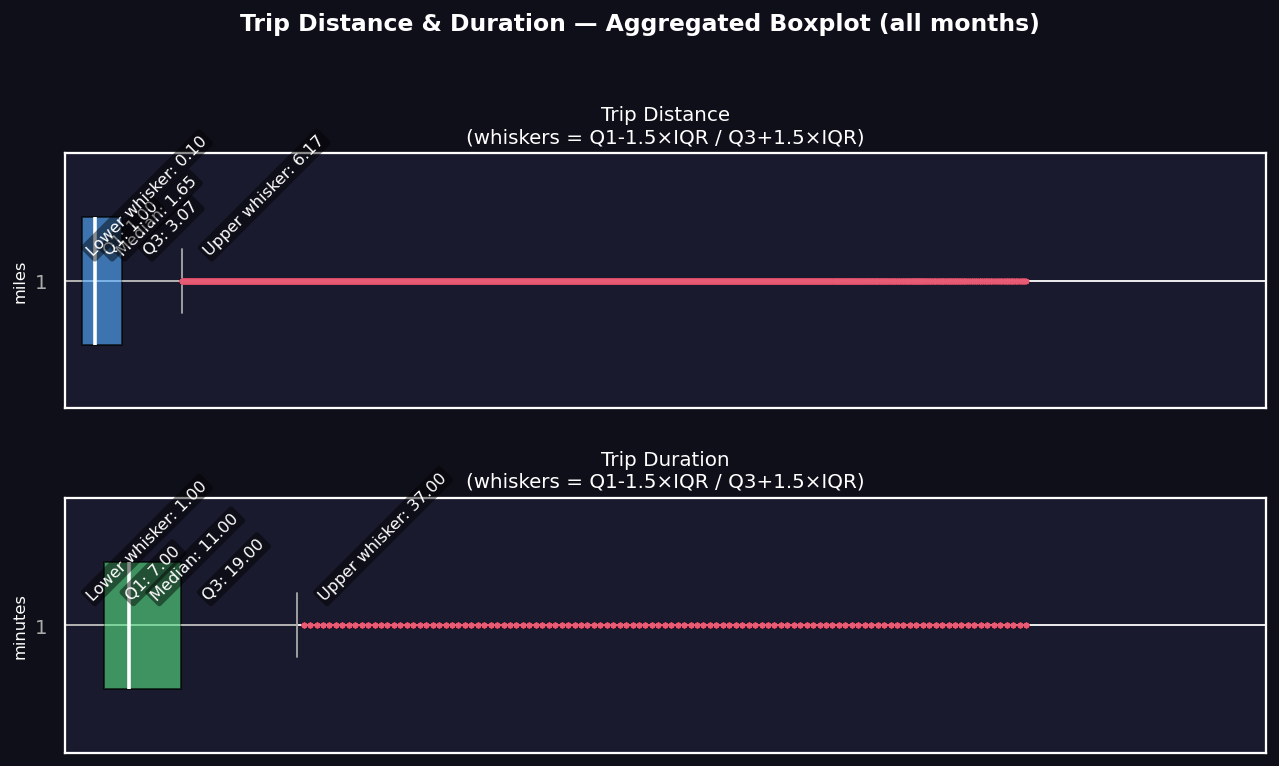

  Saved: 01b_boxplots_aggregated.png


In [24]:
# ── Figure 2: Aggregated boxplots (all months combined) ────────────────────

fig, axes = plt.subplots(2,1, figsize=(10, 6))
fig.suptitle("Trip Distance & Duration — Aggregated Boxplot (all months)",
             fontsize=13, fontweight="bold", color="white")

flierprops   = dict(marker="o", markerfacecolor="#E85D75",
                    markeredgecolor="none", markersize=3, alpha=0.3)
medianprops  = dict(color="white", linewidth=2)
whiskerprops = dict(color="#aaaaaa", linewidth=1)
capprops     = dict(color="#aaaaaa", linewidth=1)

for ax, col, color, label, unit in [
    (axes[0], "trip_distance",    "#4C9BE8", "Trip Distance", "miles"),
    (axes[1], "trip_duration_mins", "#50C878", "Trip Duration", "minutes"),
]:
    bp = ax.boxplot(df_dist[col], patch_artist=True,
                    medianprops=medianprops, flierprops=flierprops,
                    whiskerprops=whiskerprops, capprops=capprops,
                    widths=0.5, vert=False)
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.7)

    # Annotate key statistics
    q1  = df_dist[col].quantile(0.25)
    med = df_dist[col].median()
    q3  = df_dist[col].quantile(0.75)
    iqr = q3 - q1
    w_low  = max(df_dist[col].min(), q1 - 1.5 * iqr)
    w_high = min(df_dist[col].max(), q3 + 1.5 * iqr)

    kw = dict(ha="left", fontsize=9, color="white",
              bbox=dict(facecolor="black", alpha=0.45,
                        edgecolor="none", boxstyle="round,pad=0.2"))

    y_pos = 1.1
    offset = (df_dist[col].max() - df_dist[col].min()) * 0.02

    ax.text(w_high + offset, y_pos, f"Upper whisker: {w_high:.2f}", rotation=45, **kw)
    ax.text(q3 + offset, y_pos, f"Q3: {q3:.2f}", rotation=45, **kw)
    ax.text(med + offset, y_pos, f"Median: {med:.2f}", rotation=45, **kw)
    ax.text(q1 + offset, y_pos, f"Q1: {q1:.2f}", rotation=45, **kw)
    ax.text(w_low + offset, y_pos, f"Lower whisker: {w_low:.2f}", rotation=45, **kw)

    ax.set_title(f"{label}\n(whiskers = Q1-1.5×IQR / Q3+1.5×IQR)")
    ax.set_ylabel(unit)
    ax.set_xticks([])

    # Setting dynamic limits
    x_min = df_dist[col].min()
    x_max = df_dist[col].max()
    padding = (x_max - x_min) * 0.25

    ax.set_xlim(x_min, x_max + padding)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(hspace=0.35) # Add spacing between plots

plt.savefig(OUTPUT_DIR / "01b_boxplots_aggregated.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("  Saved: 01b_boxplots_aggregated.png")

In [1]:
df_stats = con.execute("""
    SELECT
        file_month,
        COUNT(*)                                          AS n_trips,
        ROUND(APPROX_QUANTILE(trip_distance, 0.25), 2)   AS dist_q1,
        ROUND(APPROX_QUANTILE(trip_distance, 0.50), 2)   AS dist_median,
        ROUND(APPROX_QUANTILE(trip_distance, 0.75), 2)   AS dist_q3,
        ROUND(AVG(trip_distance), 2)                     AS dist_mean,
        ROUND(APPROX_QUANTILE(trip_duration_mins, 0.25), 2) AS dur_q1,
        ROUND(APPROX_QUANTILE(trip_duration_mins, 0.50), 2) AS dur_median,
        ROUND(APPROX_QUANTILE(trip_duration_mins, 0.75), 2) AS dur_q3,
        ROUND(AVG(trip_duration_mins), 2)                AS dur_mean
    FROM staging_taxi_trips
    WHERE trip_distance      BETWEEN 0.1 AND 50
      AND trip_duration_mins BETWEEN 1   AND 150
    GROUP BY file_month
    ORDER BY file_month
""").fetchdf()

NameError: name 'con' is not defined

In [ ]:
# 5.3 Demand by time interval

df_time = con.execute('''
    SELECT
        file_month,
        pickup_hour                       AS hour_of_day,
        pickup_dow                        AS day_of_week,
        DAYNAME(tpep_pickup_datetime)     AS day_name,
        is_weekend,
        time_of_day,
        COUNT(*) AS trip_count
    FROM staging_taxi_trips
    WHERE trip_distance      BETWEEN 0.1 AND 50
      AND trip_duration_mins BETWEEN 1   AND 150
    GROUP BY ALL
    ORDER BY file_month, hour_of_day
''').fetchdf()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Taxi Demand -- Time Interval Analysis',
             fontsize=14, fontweight='bold', color='white')

hourly = df_time.groupby('hour_of_day')['trip_count'].mean().reset_index()
axes[0, 0].bar(hourly['hour_of_day'], hourly['trip_count'],
               color=COLORS['primary'], alpha=0.85, edgecolor='none')
axes[0, 0].set_title('Average Trips by Hour of Day')
axes[0, 0].set_xlabel('Hour (24h)')
axes[0, 0].set_ylabel('Avg Trip Count')
axes[0, 0].set_xticks(range(0, 24))

for is_wknd, label, color in [(False, 'Weekday', COLORS['primary']),
                               (True,  'Weekend', COLORS['secondary'])]:
    sub = df_time[df_time['is_weekend'] == is_wknd].groupby(
        'hour_of_day')['trip_count'].mean().reset_index()
    axes[0, 1].plot(sub['hour_of_day'], sub['trip_count'],
                    label=label, color=color, linewidth=2, marker='o', markersize=3)
axes[0, 1].set_title('Avg Trips by Hour -- Weekday vs Weekend')
axes[0, 1].set_xlabel('Hour (24h)')
axes[0, 1].set_ylabel('Avg Trip Count')
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].legend(facecolor='#1a1a2e', labelcolor='white')

day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
daily = df_time.groupby('day_name')['trip_count'].mean().reindex(day_order).reset_index()
bar_colors = [COLORS['secondary'] if d in ('Saturday','Sunday')
              else COLORS['primary'] for d in day_order]
axes[1, 0].bar(daily['day_name'], daily['trip_count'],
               color=bar_colors, alpha=0.85, edgecolor='none')
axes[1, 0].set_title('Average Trips by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Avg Trip Count')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=30, ha='right')

tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tod = df_time.groupby(['file_month','time_of_day'])['trip_count'].sum().reset_index()
tod_pivot = tod.pivot(index='file_month', columns='time_of_day',
                      values='trip_count')[tod_order]
tod_pivot.plot(kind='bar', ax=axes[1, 1], colormap='Set2', alpha=0.85, edgecolor='none')
axes[1, 1].set_title('Trip Count by Time of Day and Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Trip Count')
axes[1, 1].legend(title='Time of Day', facecolor='#1a1a2e', labelcolor='white')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_demand_time_intervals.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('  Saved: 02_demand_time_intervals.png')

In [ ]:
# 5.4 Demand by borough

try:
    con.execute('SELECT 1 FROM taxi_zones LIMIT 1')
except Exception:
    df_zones = pd.read_csv(ZONE_LOOKUP_PATH)
    df_zones.columns = df_zones.columns.str.lower().str.strip()
    con.register('taxi_zones', df_zones)

df_borough = con.execute('''
    SELECT
        t.file_month,
        z.borough AS pickup_borough,
        COUNT(*) AS trip_count,
        ROUND(AVG(t.trip_distance), 2) AS avg_distance,
        ROUND(AVG(t.trip_duration_mins), 2) AS avg_duration,
        ROUND(AVG(t.fare_amount), 2) AS avg_fare
    FROM staging_taxi_trips t
    LEFT JOIN taxi_zones z ON t.PULocationID = z.locationid
    WHERE z.borough != 'EWR'
      AND t.trip_distance      BETWEEN 0.1 AND 50
      AND t.trip_duration_mins BETWEEN 1   AND 150
    GROUP BY t.file_month, z.borough
    ORDER BY t.file_month, trip_count DESC
''').fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Taxi Demand by Borough', fontsize=14, fontweight='bold', color='white')

df_bor_pivot = df_borough.pivot(index='pickup_borough',
                                columns='file_month', values='trip_count')
df_bor_pivot.plot(kind='bar', ax=axes[0], colormap='Set2', alpha=0.85, edgecolor='none')
axes[0].set_title('Trip Count by Borough and Month')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Trip Count')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[0].legend(title='Month', facecolor='#1a1a2e', labelcolor='white')

df_fare = df_borough.groupby('pickup_borough')['avg_fare'].mean().sort_values(ascending=False)
axes[1].barh(df_fare.index, df_fare.values, color=COLORS['purple'], alpha=0.85)
axes[1].set_title('Average Fare by Borough')
axes[1].set_xlabel('Average Fare ($)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_demand_by_borough.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('  Saved: 03_demand_by_borough.png')

print('\nTop 10 pickup zones:')
display(con.execute('''
    SELECT z.zone, z.borough, COUNT(*) AS trip_count
    FROM staging_taxi_trips t
    LEFT JOIN taxi_zones z ON t.PULocationID = z.locationid
    WHERE z.borough != 'EWR'
      AND t.trip_distance      BETWEEN 0.1 AND 50
      AND t.trip_duration_mins BETWEEN 1   AND 150
    GROUP BY z.zone, z.borough
    ORDER BY trip_count DESC LIMIT 10
''').fetchdf())

## Section 6 -- Gold EDA (Weather Patterns)

Run after gold layer is built. Establishes baseline weather-demand correlations.

In [ ]:
# 6.1 Gold layer preview and sense check

display(con.execute('''
    SELECT file_month,
           COUNT(*) AS hourly_zone_records,
           SUM(trip_count) AS total_trips,
           ROUND(AVG(trip_count), 2) AS avg_trips_per_hour_zone,
           SUM(CASE WHEN temperature_2m IS NULL THEN 1 ELSE 0 END) AS missing_weather
    FROM gold_hourly_demand
    GROUP BY file_month ORDER BY file_month
''').fetchdf())

In [ ]:
# 6.2 Daily demand vs weather

# df_daily = con.execute('''
#     SELECT
#         CAST(pickup_hour_ts AS DATE) AS pickup_date,
#         file_month,
#         SUM(trip_count)              AS daily_trips,
#         AVG(temperature_2m)          AS avg_temp_c,
#         SUM(precipitation)           AS total_precip_mm,
#         SUM(snowfall)                AS total_snowfall_cm,
#         BOOL_OR(is_extreme_weather)  AS is_extreme_weather
#     FROM gold_hourly_demand
#     GROUP BY CAST(pickup_hour_ts AS DATE), file_month
#     ORDER BY pickup_date
# ''').fetchdf()

# fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# fig.suptitle('Weather Impact on Daily Taxi Demand',
#              fontsize=14, fontweight='bold', color='white')

# normal  = df_daily[~df_daily['is_extreme_weather']]
# extreme = df_daily[df_daily['is_extreme_weather']]
# axes[0, 0].scatter(normal['pickup_date'],  normal['daily_trips'],
#                    color=COLORS['primary'], alpha=0.4, s=12, label='Normal')
# axes[0, 0].scatter(extreme['pickup_date'], extreme['daily_trips'],
#                    color=COLORS['red'], alpha=0.9, s=35, zorder=5, label='Extreme weather')
# axes[0, 0].set_title('Daily Trips Over Time  |  Red = Extreme Weather Day')
# axes[0, 0].set_xlabel('Date')
# axes[0, 0].set_ylabel('Daily Trip Count')
# axes[0, 0].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

# axes[0, 1].scatter(df_daily['avg_temp_c'], df_daily['daily_trips'],
#                    color=COLORS['secondary'], alpha=0.5, s=12)
# axes[0, 1].set_title('Daily Trips vs Temperature (C)')
# axes[0, 1].set_xlabel('Avg Temperature (C)')
# axes[0, 1].set_ylabel('Daily Trip Count')

# axes[1, 0].scatter(df_daily['total_precip_mm'], df_daily['daily_trips'],
#                    color=COLORS['green'], alpha=0.5, s=12)
# axes[1, 0].set_title('Daily Trips vs Precipitation (mm)')
# axes[1, 0].set_xlabel('Total Precipitation (mm)')
# axes[1, 0].set_ylabel('Daily Trip Count')

# axes[1, 1].scatter(df_daily['total_snowfall_cm'], df_daily['daily_trips'],
#                    color=COLORS['purple'], alpha=0.5, s=12)
# axes[1, 1].set_title('Daily Trips vs Snowfall (cm)')
# axes[1, 1].set_xlabel('Total Snowfall (cm)')
# axes[1, 1].set_ylabel('Daily Trip Count')

# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / '04_weather_impact.png',
#             bbox_inches='tight', facecolor=fig.get_facecolor())
# plt.show()
# print('  Saved: 04_weather_impact.png')

# print('\nCorrelation with daily trip count:')
# corr = df_daily[['daily_trips','avg_temp_c','log_precip','log_snowfall']] \
#        .corr(method = 'spearman')['daily_trips'].drop('daily_trips')
# display(corr.reset_index().rename(columns={'index':'feature','daily_trips':'spearman_r'}))

In [ ]:
# 6.3 Hourly demand heatmap -- avg trips by hour and day of week

df_heatmap = con.execute('''
    SELECT hour_of_day, day_of_week, ROUND(AVG(trip_count), 1) AS avg_trips
    FROM gold_hourly_demand
    GROUP BY hour_of_day, day_of_week
    ORDER BY day_of_week, hour_of_day
''').fetchdf()

pivot = df_heatmap.pivot(index='day_of_week', columns='hour_of_day', values='avg_trips')
pivot.index = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), color='#aaaaaa', fontsize=8)
ax.set_yticks(range(7))
ax.set_yticklabels(pivot.index, color='#aaaaaa')
ax.set_title('Average Trip Count by Hour and Day of Week',
             color='white', fontsize=12, fontweight='bold')
ax.set_xlabel('Hour of Day', color='white')
ax.set_ylabel('Day of Week', color='white')
plt.colorbar(im, ax=ax, label='Avg Trip Count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_demand_heatmap.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('  Saved: 05_demand_heatmap.png')

In [ ]:
# 6.2 Daily demand vs weather

df_daily = con.execute('''
  WITH aggregated_gold_results AS(
    SELECT
        CAST(pickup_hour_ts AS DATE) AS pickup_date,
        file_month,
        SUM(trip_count)              AS daily_trips,
        AVG(temperature_2m)          AS avg_temp_c,
        SUM(precipitation)           AS total_precip_mm,
        SUM(snowfall)                AS total_snowfall_cm,
        BOOL_OR(is_extreme_weather)  AS is_extreme_weather
    FROM gold_hourly_demand
    GROUP BY CAST(pickup_hour_ts AS DATE), file_month
    ORDER BY pickup_date
  )

  SELECT aggregated_gold_results.*,
        LOG(total_precip_mm + 1) AS log_precip,
        LOG(total_snowfall_cm + 1) AS log_snowfall
  FROM aggregated_gold_results
  WHERE (total_precip_mm < 1000) OR (total_snowfall_cm < 200)

''').fetchdf()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Weather Impact on Daily Taxi Demand',
             fontsize=14, fontweight='bold', color='white')

normal  = df_daily[~df_daily['is_extreme_weather']]
extreme = df_daily[df_daily['is_extreme_weather']]
axes[0, 0].scatter(normal['pickup_date'],  normal['daily_trips'],
                   color=COLORS['primary'], alpha=0.4, s=12, label='Normal')
axes[0, 0].scatter(extreme['pickup_date'], extreme['daily_trips'],
                   color=COLORS['red'], alpha=0.9, s=35, zorder=5, label='Extreme weather')
axes[0, 0].set_title('Daily Trips Over Time  |  Red = Extreme Weather Day')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Daily Trip Count')
axes[0, 0].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

axes[0, 1].scatter(df_daily['avg_temp_c'], df_daily['daily_trips'],
                   color=COLORS['secondary'], alpha=0.5, s=12)
axes[0, 1].set_title('Daily Trips vs Temperature (C)')
axes[0, 1].set_xlabel('Avg Temperature (C)')
axes[0, 1].set_ylabel('Daily Trip Count')

axes[1, 0].scatter(df_daily['log_precip'], df_daily['daily_trips'],
                   color=COLORS['green'], alpha=0.5, s=12)
axes[1, 0].set_title('Daily Trips vs Log Precipitation')
axes[1, 0].set_xlabel('Total Log Precipitation')
axes[1, 0].set_ylabel('Daily Trip Count')

axes[1, 1].scatter(df_daily['log_snowfall'], df_daily['daily_trips'],
                   color=COLORS['purple'], alpha=0.5, s=12)
axes[1, 1].set_title('Daily Trips vs Log Snowfall')
axes[1, 1].set_xlabel('Total Log Snowfall')
axes[1, 1].set_ylabel('Daily Trip Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_weather_impact_log_transformed.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('  Saved: 04_weather_impact_log_transformed.png')

print('\nCorrelation with daily trip count:')
corr = df_daily[['daily_trips','avg_temp_c','log_precip','log_snowfall']] \
       .corr(method = 'spearman')['daily_trips'].drop('daily_trips')
display(corr.reset_index().rename(columns={'index':'feature','daily_trips':'spearman_r'}))

# Section 7 -- Baseline Modelling


**Objective:** Establish whether LightGBM can train on gold layer data and produce a sensible baseline MAE.

Start with 3 months, scale up once confirmed working.

In [ ]:
# ── Step 1: Pull features from gold layer ─────────────────────────────────
# Start with 3 months only — scale once confirmed working
TRAIN_MONTHS = ["2019-01", "2019-02", "2019-03","2019-04","2019-05","2019-06",
                "2019-07","2019-08","2019-09"]

months_str = ", ".join(f"'{m}'" for m in TRAIN_MONTHS)

df_gold = con.execute(f"""
    SELECT
        pickup_hour_ts,
        -- Target
        trip_count,
        -- Time features
        hour_of_day,
        day_of_week,
        is_weekend,
        MONTH(pickup_hour_ts)   AS month_of_year,
        -- Location features
        PULocationID,
        -- Weather features
        temperature_2m,
        precipitation,
        snowfall,
        windspeed_10m,
        CAST(is_snowing         AS INTEGER) AS is_snowing,
        CAST(is_raining         AS INTEGER) AS is_raining,
        CAST(is_extreme_weather AS INTEGER) AS is_extreme_weather
    FROM gold_hourly_demand
    WHERE file_month IN ({months_str})
      AND trip_count > 0          -- exclude hours with no trips
      AND borough != 'Unknown'    -- exclude unknown zones
""").fetchdf()

print(f"Gold rows loaded: {len(df_gold):,}")
print(f"Months: {df_gold['month_of_year'].unique()}")
print(f"Target range: {df_gold['trip_count'].min()} - {df_gold['trip_count'].max()}")
print(f"Missing values:\n{df_gold.isnull().sum()[df_gold.isnull().sum() > 0]}")

Gold rows loaded: 821,039
Months: [ 2  3  1  4  6  5  8  9  7 12 10 11]
Target range: 1 - 1384
Missing values:
Series([], dtype: int64)


In [ ]:
# ── Step 2: Train/validation split ────────────────────────────────────────
# Important: do NOT use random split for time series data.
# Use the last 20% of time as validation — preserves temporal order.

df_gold = df_gold.sort_values("pickup_hour_ts").reset_index(drop=True)

FEATURES = [
    "hour_of_day", "day_of_week", "is_weekend", "month_of_year",
    "PULocationID",
    "temperature_2m", "precipitation", "snowfall", "windspeed_10m",
    "is_snowing", "is_raining", "is_extreme_weather",
]
TARGET = "trip_count"

split_idx = int(len(df_gold) * 0.8)
df_train = df_gold.iloc[:split_idx]
df_val   = df_gold.iloc[split_idx:]

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET]

print(f"Train: {len(X_train):,} rows")
print(f"Val:   {len(X_val):,} rows")

Train: 656,831 rows
Val:   164,208 rows


In [ ]:
# ── Step 3: Train baseline LightGBM ───────────────────────────────────────
# These are conservative starter params — not tuned yet.
# Record results in BM1 before changing anything.

params = {
    "objective":       "regression",
    "metric":          "mae",
    "n_estimators":    2000,
    "learning_rate":   0.05,
    "num_leaves":      63,
    "min_child_samples": 20,
    "subsample":       0.8,
    "colsample_bytree": 0.8,
    "random_state":    42,
    "verbose":         -1,
}

# After building df_gold
df_gold["PULocationID"] = df_gold["PULocationID"].astype("category")

model = lgb.LGBMRegressor(**params)

# Then in the model call, declare categorical features
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    categorical_feature=["PULocationID"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100),
    ]
)

# ── Step 4: Evaluate ───────────────────────────────────────────────────────
y_pred = model.predict(X_val)
y_pred = np.clip(y_pred, 0, None)   # trip count can't be negative

mae  = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
# Normalised MAE — easier to interpret than raw MAE
nmae = mae / y_val.mean()

print(f"\n── BM1 Results ─────────────────────────────────────────")
print(f"  MAE:              {mae:.3f} trips")
print(f"  RMSE:             {rmse:.3f} trips")
print(f"  Normalised MAE:   {nmae:.3%}  (MAE / mean trip count)")
print(f"  Mean trip count:  {y_val.mean():.2f}")
print(f"  Best iteration:   {model.best_iteration_}")
print(f"  Months trained:   {TRAIN_MONTHS}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 16.489
[200]	valid_0's l1: 14.9818
[300]	valid_0's l1: 14.6117
[400]	valid_0's l1: 14.4292
[500]	valid_0's l1: 14.2457
[600]	valid_0's l1: 14.1769
[700]	valid_0's l1: 14.1545
[800]	valid_0's l1: 14.0156
[900]	valid_0's l1: 13.9081
Early stopping, best iteration is:
[915]	valid_0's l1: 13.9002

── BM1 Results ─────────────────────────────────────────
  MAE:              13.684 trips
  RMSE:             31.648 trips
  Normalised MAE:   19.100%  (MAE / mean trip count)
  Mean trip count:  71.65
  Best iteration:   915
  Months trained:   ['2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09']


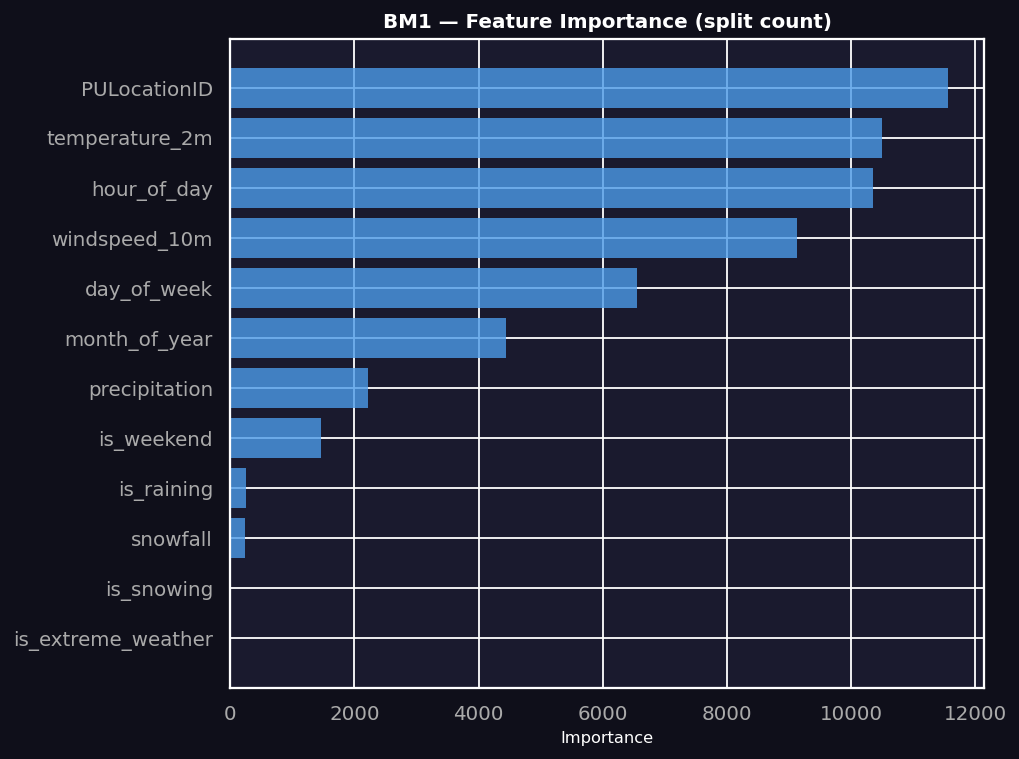

In [ ]:
# ── Step 5: Feature importance ─────────────────────────────────────────────
# This tells you which features are actually driving predictions.
# Useful for your proposal and for deciding whether weather adds value.

fi = pd.DataFrame({
    "feature":    FEATURES,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi["feature"], fi["importance"],
        color="#4C9BE8", alpha=0.8, edgecolor="none")
ax.set_title("BM1 — Feature Importance (split count)",
             color="white", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "BM1_feature_importance.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

In [ ]:
# ── Step 6: Log results to experiment tracker ──────────────────────────────
# Record these numbers in your experiment log under BM1

bm1_results = {
    "Experiment ID":  "BM1",
    "Train months":   str(TRAIN_MONTHS),
    "Train rows":     len(X_train),
    "Val rows":       len(X_val),
    "Features":       str(FEATURES),
    "MAE":            round(mae, 4),
    "RMSE":           round(rmse, 4),
    "Normalised MAE": round(nmae, 4),
    "Best iteration": model.best_iteration_,
    "n_estimators":   params["n_estimators"],
    "num_leaves":     params["num_leaves"],
    "learning_rate":  params["learning_rate"],
}

for k, v in bm1_results.items():
    print(f"  {k}: {v}")

  Experiment ID: BM1
  Train months: ['2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09']
  Train rows: 656831
  Val rows: 164208
  Features: ['hour_of_day', 'day_of_week', 'is_weekend', 'month_of_year', 'PULocationID', 'temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m', 'is_snowing', 'is_raining', 'is_extreme_weather']
  MAE: 13.6839
  RMSE: 31.6481
  Normalised MAE: 0.191
  Best iteration: 915
  n_estimators: 2000
  num_leaves: 63
  learning_rate: 0.05
